#### 04 - Exploratory Data Analysis (EDA)
##### Objective
Perform univariate, bivariate, and multivariate exploratory data analysis on the engineered Home Credit dataset.
The analysis focuses on:

- Customer characteristics
- Income and credit distributions
- Loan application behaviour
- Affordability ratios
- Default-risk patterns
- Relationships between important numerical and categorical variables
- Correlation between numerical variables

#### 1. Import Required Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

#### 2. Load Engineered Dataset

In [9]:
# Load the engineered application dataset
df = pd.read_csv(r"D:\Home_credit\processed_data\application_train_engineered.csv")
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE_YEARS,EMPLOYMENT_YEARS,AGE_GROUP,EMPLOYMENT_GROUP,INCOME_GROUP,CREDIT_TO_INCOME,ANNUITY_TO_INCOME,GOODS_TO_INCOME,CREDIT_TO_GOODS,INCOME_PER_FAMILY_MEMBER
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,25.9,1.7,20–30,1–3 Years,High,2.007889,0.121978,1.733333,1.158397,202500.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,45.9,3.3,41–50,3–5 Years,Very High,4.790750,0.132217,4.183333,1.145199,135000.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Se

In [10]:
df.shape

(307511, 132)

In [11]:
# Display basic descriptive statistics for numerical columns
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE_YEARS,EMPLOYMENT_YEARS,CREDIT_TO_INCOME,ANNUITY_TO_INCOME,GOODS_TO_INCOME,CREDIT_TO_GOODS,INCOME_PER_FAMILY_MEMBER
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,104582.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307509.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,134133.000000,3.068510e+05,246546.000000,151450.00000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,151450.000000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,151450.000000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,159080.000000,306490.000000,306490.000000,306490.000000,306490.000000,307510.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.00000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,307511.000000,252137.000000,307511.000000,307499.000000,307233.000000,307233.000000,3.075090e+05
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,-4986.120328,-2994.202373,12.061091,0.999997,0.819889,0.199368,0.998133,0.281066,0.056720,2.152665,2.052463,2.031521,12.063419,0.015144,0.050769,0.040659,0.078173,0.230454,0.179555,0.502130,5.143927e-01,0.510853,0.11744,0.088442,0.977735,0.752471,0.044621,0.078942,0.14

In [12]:
# Display descriptive statistics for categorical columns
df.describe(include="object")

C:\Users\Dell\AppData\Local\Temp\ipykernel_23216\2400710736.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,WEEKDAY_APPR_PROCESS_START,ORGANIZATION_TYPE,FONDKAPREMONT_MODE,HOUSETYPE_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,AGE_GROUP,EMPLOYMENT_GROUP,INCOME_GROUP
count,307511,307511,307511,307511,306219,307511,307511,307511,307511,211120,307511,307511,97216,153214,151170,161756,307511,307511,307511
unique,2,3,2,2,7,8,5,6,6,18,7,58,4,3,7,2,5,7,5
top,Cash loans,F,N,Y,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,Laborers,TUESDAY,Business Entity Type 3,reg oper account,block of flats,Panel,No,31–40,5–10 Years,Low
freq,278232,202448,202924,213312,248526,158774,218391,196432,272868,55186,53901,67992,73830,150503,66040,159428,82413,65436,85756


In [13]:
# Display all column names in the engineered dataset
df.columns.tolist()

['SK_ID_CURR',
 'TARGET',
 'NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'REGION_POPULATION_RELATIVE',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'DAYS_REGISTRATION',
 'DAYS_ID_PUBLISH',
 'OWN_CAR_AGE',
 'FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'OCCUPATION_TYPE',
 'CNT_FAM_MEMBERS',
 'REGION_RATING_CLIENT',
 'REGION_RATING_CLIENT_W_CITY',
 'WEEKDAY_APPR_PROCESS_START',
 'HOUR_APPR_PROCESS_START',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'LIVE_CITY_NOT_WORK_CITY',
 'ORGANIZATION_TYPE',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'APARTMENTS_AVG',
 'BASEMENTAREA_AVG',
 'YEARS_BEGINEXPLUATATION_A

In [14]:
# Check the data types of all columns

df.dtypes

SK_ID_CURR                    int64
TARGET                        int64
NAME_CONTRACT_TYPE              str
CODE_GENDER                     str
FLAG_OWN_CAR                    str
                             ...   
CREDIT_TO_INCOME            float64
ANNUITY_TO_INCOME           float64
GOODS_TO_INCOME             float64
CREDIT_TO_GOODS             float64
INCOME_PER_FAMILY_MEMBER    float64
Length: 132, dtype: object

In [15]:
# Check the distribution of the TARGET variable
df["TARGET"].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [16]:
# Calculate the overall default rate
default_rate = df["TARGET"].mean() * 100
default_rate

np.float64(8.072881945686495)

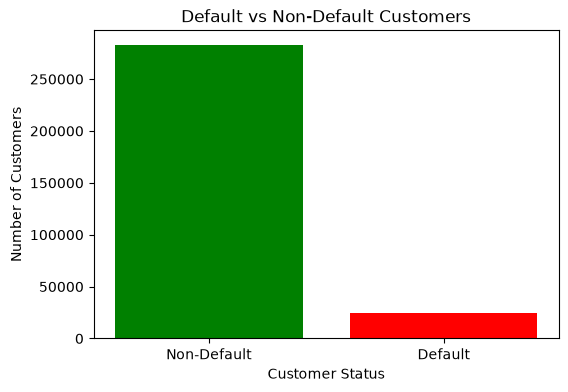

In [18]:
import matplotlib.pyplot as plt

# Count default and non-default customers
target_counts = df["TARGET"].value_counts().sort_index()

# Create bar chart
plt.figure(figsize=(6, 4))
plt.bar(
    ["Non-Default", "Default"],
    target_counts.values,
    color=["green", "red"]
)

plt.title("Default vs Non-Default Customers")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.show()

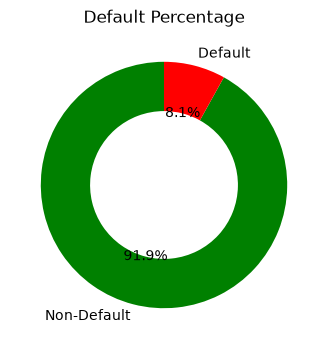

In [20]:
import matplotlib.pyplot as plt

default_counts = df["TARGET"].value_counts()

labels = ["Non-Default", "Default"]
values = [
    default_counts.get(0, 0),
    default_counts.get(1, 0)
]

plt.figure(figsize=(4, 4))

plt.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=["green", "red"],
    wedgeprops={"width": 0.4}
)

plt.title("Default Percentage")
plt.show()

In [21]:
# Check the age group categories
df["AGE_GROUP"].value_counts()

AGE_GROUP
31–40    82413
41–50    76479
51–60    68080
20–30    45530
60+      35009
Name: count, dtype: int64

In [22]:
# Calculate observed default rate by age group
age_default_rate = (
    df.groupby("AGE_GROUP")["TARGET"]
    .mean()
    .mul(100)
    .round(2)
    .sort_index()
)

age_default_rate

AGE_GROUP
20–30    11.43
31–40     9.58
41–50     7.63
51–60     6.10
60+       4.94
Name: TARGET, dtype: float64

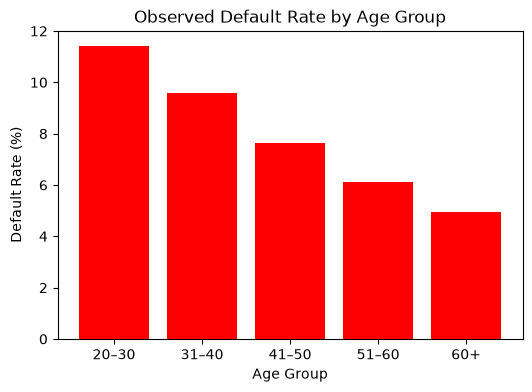

In [23]:
# Visualize observed default rate by age group
plt.figure(figsize=(6, 4))

plt.bar(
    age_default_rate.index,
    age_default_rate.values,
    color="red"
)

plt.title("Observed Default Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Default Rate (%)")

plt.show()

In [24]:
# Check income group categories
df["INCOME_GROUP"].value_counts()

INCOME_GROUP
Low          85756
High         75513
Very Low     63671
Very High    47118
Middle       35453
Name: count, dtype: int64

In [25]:
# Calculate observed default rate by income group
income_default_rate = (
    df.groupby("INCOME_GROUP")["TARGET"]
    .mean()
    .mul(100)
    .round(2)
)

income_default_rate

INCOME_GROUP
High         8.06
Low          8.59
Middle       8.68
Very High    6.52
Very Low     8.21
Name: TARGET, dtype: float64

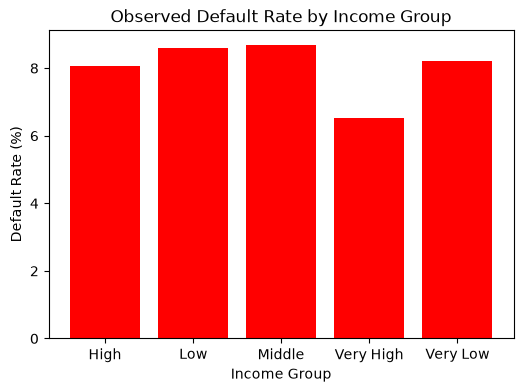

In [26]:
# Visualize observed default rate by income group
plt.figure(figsize=(6, 4))

plt.bar(
    income_default_rate.index,
    income_default_rate.values,
    color="red"
)

plt.title("Observed Default Rate by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Default Rate (%)")

plt.show()

In [27]:
# Check employment group categories
df["EMPLOYMENT_GROUP"].value_counts()

EMPLOYMENT_GROUP
5–10 Years              65436
1–3 Years               61704
Unemployed / Special    55374
3–5 Years               47271
10–20 Years             38719
<1 Year                 26366
20+ Years               12641
Name: count, dtype: int64

In [28]:
# Calculate observed default rate by employment group

employment_default_rate = (
    df.groupby("EMPLOYMENT_GROUP")["TARGET"]
    .mean()
    .mul(100)
    .round(2)
)

employment_default_rate

EMPLOYMENT_GROUP
10–20 Years              5.51
1–3 Years               11.09
20+ Years                4.19
3–5 Years                9.68
5–10 Years               7.39
<1 Year                 11.07
Unemployed / Special     5.40
Name: TARGET, dtype: float64

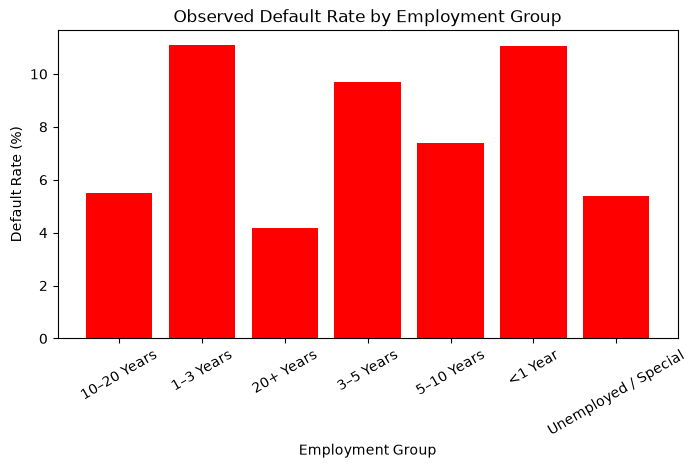

In [29]:
# Visualize observed default rate by employment group
plt.figure(figsize=(8, 4))

plt.bar(
    employment_default_rate.index,
    employment_default_rate.values,
    color="red"
)

plt.title("Observed Default Rate by Employment Group")
plt.xlabel("Employment Group")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=30)

plt.show()

In [30]:
# Check education categories
df["NAME_EDUCATION_TYPE"].value_counts()

NAME_EDUCATION_TYPE
Secondary / secondary special    218391
Higher education                  74863
Incomplete higher                 10277
Lower secondary                    3816
Academic degree                     164
Name: count, dtype: int64

In [31]:
# Calculate observed default rate by education level
education_default_rate = (
    df.groupby("NAME_EDUCATION_TYPE")["TARGET"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

education_default_rate

NAME_EDUCATION_TYPE
Lower secondary                  10.93
Secondary / secondary special     8.94
Incomplete higher                 8.48
Higher education                  5.36
Academic degree                   1.83
Name: TARGET, dtype: float64

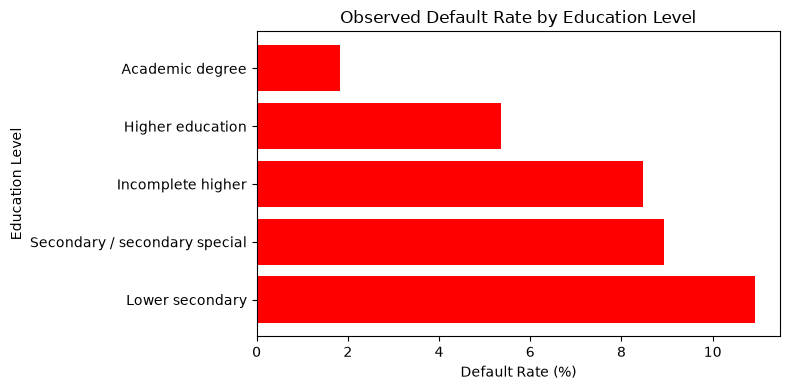

In [32]:
# Visualize observed default rate by education level
plt.figure(figsize=(8, 4))

plt.barh(
    education_default_rate.index,
    education_default_rate.values,
    color="red"
)

plt.title("Observed Default Rate by Education Level")
plt.xlabel("Default Rate (%)")
plt.ylabel("Education Level")

plt.tight_layout()
plt.show()

In [33]:
# Check contract type categories
df["NAME_CONTRACT_TYPE"].value_counts()

NAME_CONTRACT_TYPE
Cash loans         278232
Revolving loans     29279
Name: count, dtype: int64

In [34]:
# Calculate observed default rate by contract type

contract_default_rate = (
    df.groupby("NAME_CONTRACT_TYPE")["TARGET"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

contract_default_rate

NAME_CONTRACT_TYPE
Cash loans         8.35
Revolving loans    5.48
Name: TARGET, dtype: float64

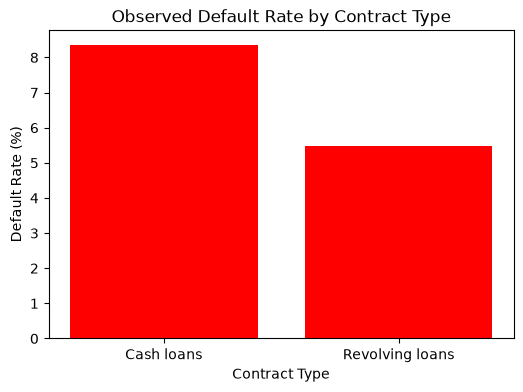

In [35]:
# Visualize observed default rate by contract type
plt.figure(figsize=(6, 4))

plt.bar(
    contract_default_rate.index,
    contract_default_rate.values,
    color="red"
)

plt.title("Observed Default Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Default Rate (%)")

plt.show()

In [36]:
# Check occupation categories
df["OCCUPATION_TYPE"].value_counts()

OCCUPATION_TYPE
Laborers                 55186
Sales staff              32102
Core staff               27570
Managers                 21371
Drivers                  18603
High skill tech staff    11380
Accountants               9813
Medicine staff            8537
Security staff            6721
Cooking staff             5946
Cleaning staff            4653
Private service staff     2652
Low-skill Laborers        2093
Waiters/barmen staff      1348
Secretaries               1305
Realty agents              751
HR staff                   563
IT staff                   526
Name: count, dtype: int64

In [37]:
# Calculate observed default rate by occupation
occupation_default_rate = (
    df.groupby("OCCUPATION_TYPE")["TARGET"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

occupation_default_rate

OCCUPATION_TYPE
Low-skill Laborers       17.15
Drivers                  11.33
Waiters/barmen staff     11.28
Security staff           10.74
Laborers                 10.58
Cooking staff            10.44
Sales staff               9.63
Cleaning staff            9.61
Realty agents             7.86
Secretaries               7.05
Medicine staff            6.70
Private service staff     6.60
IT staff                  6.46
HR staff                  6.39
Core staff                6.30
Managers                  6.21
High skill tech staff     6.16
Accountants               4.83
Name: TARGET, dtype: float64

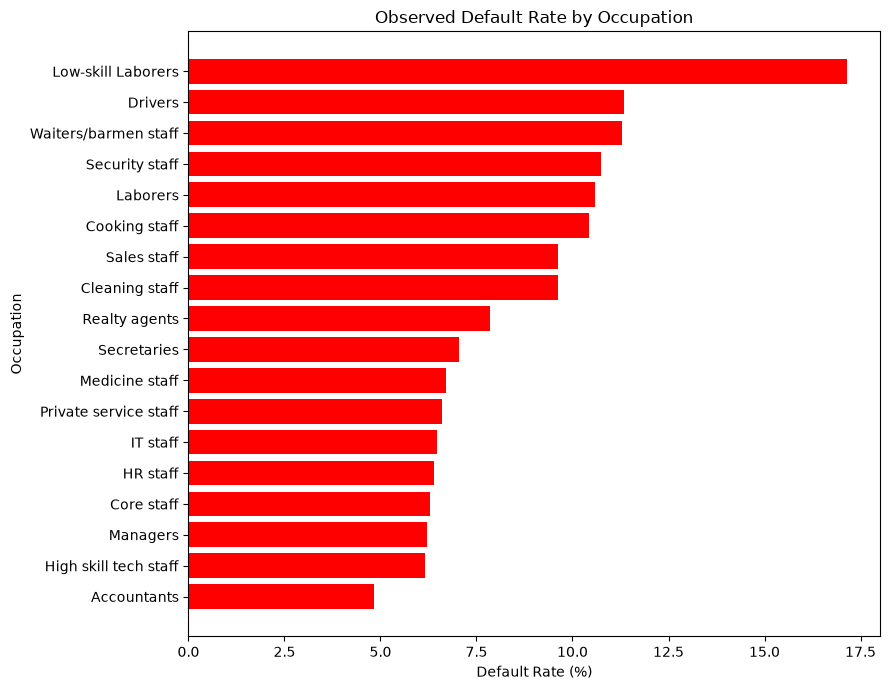

In [38]:
# Visualize observed default rate by occupation
plt.figure(figsize=(9, 7))

plt.barh(
    occupation_default_rate.index,
    occupation_default_rate.values,
    color="red"
)

plt.title("Observed Default Rate by Occupation")
plt.xlabel("Default Rate (%)")
plt.ylabel("Occupation")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [39]:
# Compare credit amount by default status
credit_by_default = (
    df.groupby("TARGET")["AMT_CREDIT"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

credit_by_default

,count,mean,median,min,max
TARGET,,,,,
0,282686,602648.28,517788.0,45000.0,4050000.0
1,24825,557778.53,497520.0,45000.0,4027680.0


<Figure size 700x500 with 0 Axes>

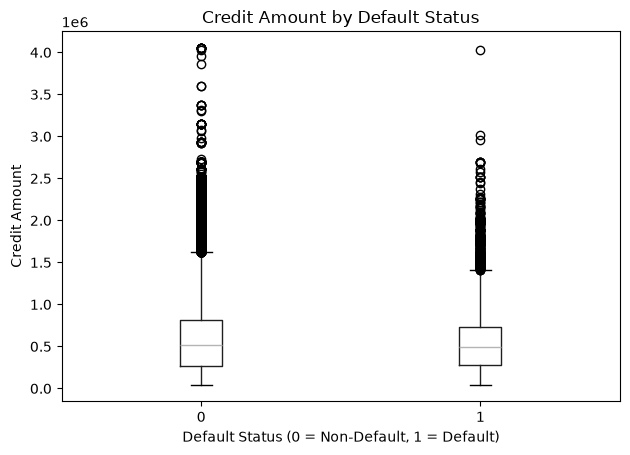

In [40]:
# Visualize credit amount by default status
plt.figure(figsize=(7, 5))

df.boxplot(
    column="AMT_CREDIT",
    by="TARGET",
    grid=False
)

plt.title("Credit Amount by Default Status")
plt.suptitle("")
plt.xlabel("Default Status (0 = Non-Default, 1 = Default)")
plt.ylabel("Credit Amount")

plt.tight_layout()
plt.show()

In [41]:
# Check the Credit-to-Income ratio
df["CREDIT_TO_INCOME"].describe()

count    307511.000000
mean          3.957570
std           2.689728
min           0.004808
25%           2.018667
50%           3.265067
75%           5.159880
max          84.736842
Name: CREDIT_TO_INCOME, dtype: float64

In [42]:
# Compare Credit-to-Income ratio by default status
credit_income_by_default = (
    df.groupby("TARGET")["CREDIT_TO_INCOME"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

credit_income_by_default

,count,mean,median,min,max
TARGET,,,,,
0,282686,3.96,3.27,0.04,49.23
1,24825,3.89,3.25,0.00,84.74


In [44]:
# Create Credit-to-Income bands for EDA

df["CREDIT_TO_INCOME_BAND"] = pd.cut(
    df["CREDIT_TO_INCOME"],
    bins=[0, 2, 4, 6, 10, float("inf")],
    labels=[
        "0-2",
        "2-4",
        "4-6",
        "6-10",
        "10+"
    ],
    include_lowest=True
)

df["CREDIT_TO_INCOME_BAND"].value_counts().sort_index()

CREDIT_TO_INCOME_BAND
0-2      76338
2-4     113561
4-6      62887
6-10     44881
10+       9844
Name: count, dtype: int64

In [45]:
# Calculate observed default rate by Credit-to-Income band
credit_income_band_default = (
    df.groupby("CREDIT_TO_INCOME_BAND", observed=True)["TARGET"]
    .mean()
    .mul(100)
    .round(2)
)

credit_income_band_default

CREDIT_TO_INCOME_BAND
0-2     7.43
2-4     8.87
4-6     8.13
6-10    7.34
10+     6.84
Name: TARGET, dtype: float64

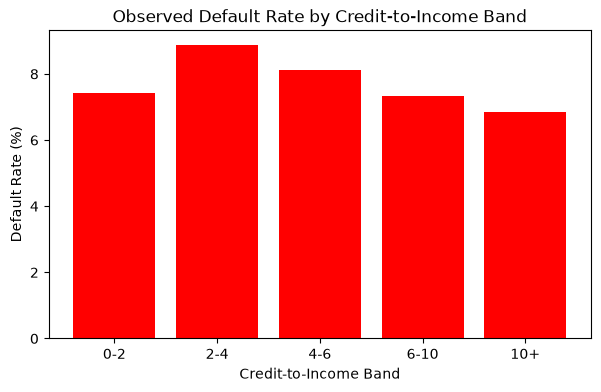

In [46]:
# Visualize observed default rate by Credit-to-Income band
plt.figure(figsize=(7, 4))

plt.bar(
    credit_income_band_default.index.astype(str),
    credit_income_band_default.values,
    color="red"
)

plt.title("Observed Default Rate by Credit-to-Income Band")
plt.xlabel("Credit-to-Income Band")
plt.ylabel("Default Rate (%)")

plt.show()

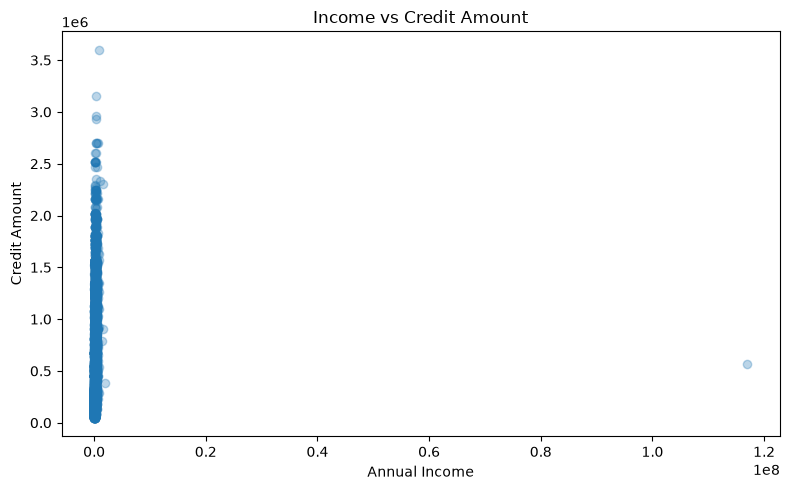

In [47]:
# Visualize Income vs Credit using a sample
sample_df = df.sample(
    n=10000,
    random_state=42
)

plt.figure(figsize=(8, 5))

plt.scatter(
    sample_df["AMT_INCOME_TOTAL"],
    sample_df["AMT_CREDIT"],
    alpha=0.3
)

plt.title("Income vs Credit Amount")
plt.xlabel("Annual Income")
plt.ylabel("Credit Amount")

plt.tight_layout()
plt.show()

In [48]:
# Check Annuity-to-Income ratio

df["ANNUITY_TO_INCOME"].describe()

count    307499.000000
mean          0.180930
std           0.094574
min           0.000224
25%           0.114782
50%           0.162833
75%           0.229067
max           1.875965
Name: ANNUITY_TO_INCOME, dtype: float64

In [49]:
# Create Annuity-to-Income bands for EDA
df["ANNUITY_TO_INCOME_BAND"] = pd.cut(
    df["ANNUITY_TO_INCOME"],
    bins=[0, 0.10, 0.20, 0.30, 0.40, float("inf")],
    labels=[
        "0–10%",
        "10–20%",
        "20–30%",
        "30–40%",
        "40%+"
    ],
    include_lowest=True
)

df["ANNUITY_TO_INCOME_BAND"].value_counts().sort_index()

C:\Users\Dell\AppData\Local\Temp\ipykernel_23216\3645820044.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["ANNUITY_TO_INCOME_BAND"] = pd.cut(


ANNUITY_TO_INCOME_BAND
0–10%      57210
10–20%    145231
20–30%     73742
30–40%     23407
40%+        7909
Name: count, dtype: int64

In [50]:
# Calculate observed default rate by Annuity-to-Income band
annuity_income_band_default = (
    df.groupby("ANNUITY_TO_INCOME_BAND", observed=True)["TARGET"]
    .mean()
    .mul(100)
    .round(2)
)

annuity_income_band_default

ANNUITY_TO_INCOME_BAND
0–10%     7.18
10–20%    8.06
20–30%    8.76
30–40%    8.13
40%+      8.27
Name: TARGET, dtype: float64

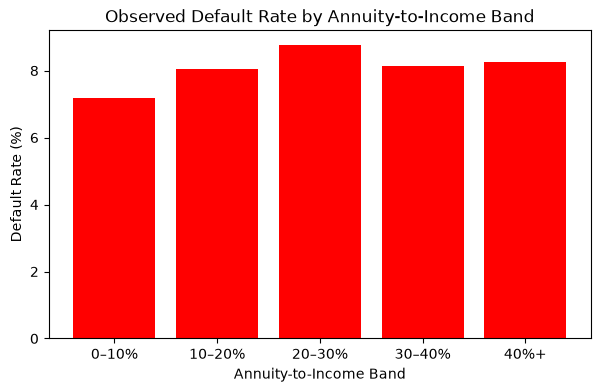

In [51]:
# Visualize observed default rate by Annuity-to-Income band
plt.figure(figsize=(7, 4))

plt.bar(
    annuity_income_band_default.index.astype(str),
    annuity_income_band_default.values,
    color="red"
)

plt.title("Observed Default Rate by Annuity-to-Income Band")
plt.xlabel("Annuity-to-Income Band")
plt.ylabel("Default Rate (%)")

plt.show()

<Figure size 800x500 with 0 Axes>

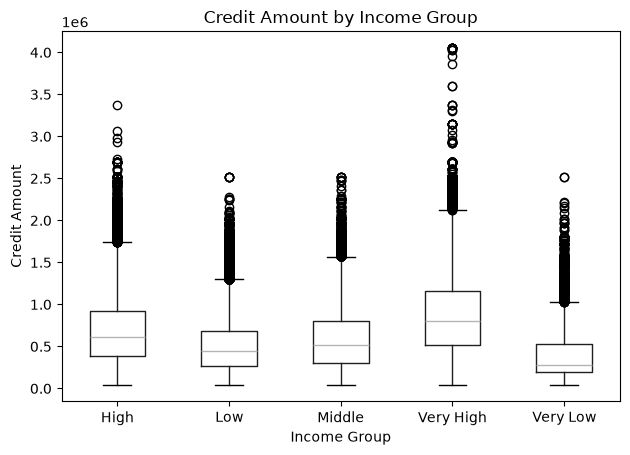

In [52]:
# Compare credit amount across income groups
plt.figure(figsize=(8, 5))

df.boxplot(
    column="AMT_CREDIT",
    by="INCOME_GROUP",
    grid=False
)

plt.title("Credit Amount by Income Group")
plt.suptitle("")
plt.xlabel("Income Group")
plt.ylabel("Credit Amount")

plt.tight_layout()
plt.show()

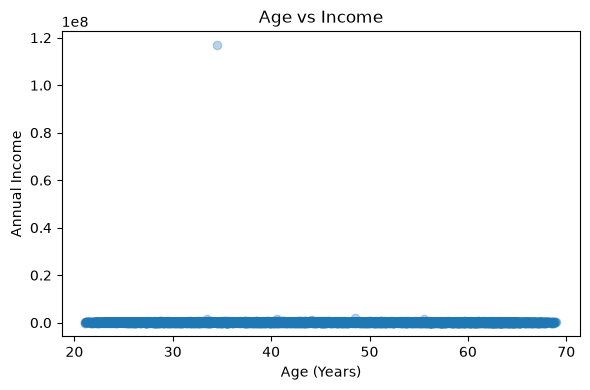

In [54]:
# Visualize Age vs Income using a sample

sample_df = df.sample(
    n=10000,
    random_state=42
)

plt.figure(figsize=(6, 4))

plt.scatter(
    sample_df["AGE_YEARS"],
    sample_df["AMT_INCOME_TOTAL"],
    alpha=0.3
)

plt.title("Age vs Income")
plt.xlabel("Age (Years)")
plt.ylabel("Annual Income")

plt.tight_layout()
plt.show()

In [55]:
# Check family size distribution
df["CNT_FAM_MEMBERS"].value_counts().sort_index().head(15)

CNT_FAM_MEMBERS
1.0      67847
2.0     158357
3.0      52601
4.0      24697
5.0       3478
6.0        408
7.0         81
8.0         20
9.0          6
10.0         3
11.0         1
12.0         2
13.0         1
14.0         2
15.0         1
Name: count, dtype: int64

In [56]:
# Create family size groups for EDA
df["FAMILY_SIZE_GROUP"] = pd.cut(
    df["CNT_FAM_MEMBERS"],
    bins=[0, 1, 2, 3, 4, float("inf")],
    labels=[
        "1",
        "2",
        "3",
        "4",
        "5+"
    ],
    include_lowest=True
)

df["FAMILY_SIZE_GROUP"].value_counts().sort_index()

C:\Users\Dell\AppData\Local\Temp\ipykernel_23216\254785261.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["FAMILY_SIZE_GROUP"] = pd.cut(


FAMILY_SIZE_GROUP
1      67847
2     158357
3      52601
4      24697
5+      4007
Name: count, dtype: int64

In [57]:
# Calculate observed default rate by family size group
family_default_rate = (
    df.groupby("FAMILY_SIZE_GROUP", observed=True)["TARGET"]
    .mean()
    .mul(100)
    .round(2)
)

family_default_rate

FAMILY_SIZE_GROUP
1     8.36
2     7.58
3     8.76
4     8.65
5+    9.91
Name: TARGET, dtype: float64

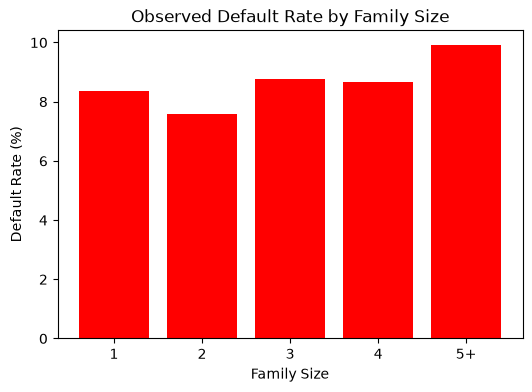

In [58]:
# Visualize observed default rate by family size
plt.figure(figsize=(6, 4))

plt.bar(
    family_default_rate.index.astype(str),
    family_default_rate.values,
    color="red"
)

plt.title("Observed Default Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Default Rate (%)")

plt.show()

In [59]:
# Check children distribution
df["CNT_CHILDREN"].value_counts().sort_index().head(15)

CNT_CHILDREN
0     215371
1      61119
2      26749
3       3717
4        429
5         84
6         21
7          7
8          2
9          2
10         2
11         1
12         2
14         3
19         2
Name: count, dtype: int64

In [60]:
# Create children groups for EDA
df["CHILDREN_GROUP"] = pd.cut(
    df["CNT_CHILDREN"],
    bins=[-1, 0, 1, 2, float("inf")],
    labels=[
        "0",
        "1",
        "2",
        "3+"
    ]
)

df["CHILDREN_GROUP"].value_counts().sort_index()

C:\Users\Dell\AppData\Local\Temp\ipykernel_23216\2415987365.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["CHILDREN_GROUP"] = pd.cut(


CHILDREN_GROUP
0     215371
1      61119
2      26749
3+      4272
Name: count, dtype: int64

In [61]:
# Calculate observed default rate by children group
children_default_rate = (
    df.groupby("CHILDREN_GROUP", observed=True)["TARGET"]
    .mean()
    .mul(100)
    .round(2)
)

children_default_rate

CHILDREN_GROUP
0      7.71
1      8.92
2      8.72
3+    10.04
Name: TARGET, dtype: float64

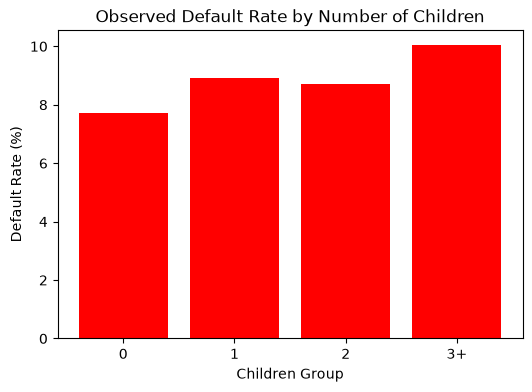

In [62]:
# Visualize observed default rate by children group
plt.figure(figsize=(6, 4))

plt.bar(
    children_default_rate.index.astype(str),
    children_default_rate.values,
    color="red"
)

plt.title("Observed Default Rate by Number of Children")
plt.xlabel("Children Group")
plt.ylabel("Default Rate (%)")

plt.show()

In [63]:
# Check gender categories
df["CODE_GENDER"].value_counts()

CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

In [64]:
# Calculate observed default rate by gender
gender_default_rate = (
    df.groupby("CODE_GENDER")["TARGET"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

gender_default_rate

CODE_GENDER
M      10.14
F       7.00
XNA     0.00
Name: TARGET, dtype: float64

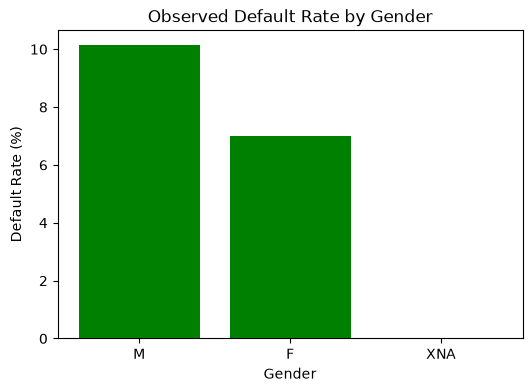

In [65]:
# Visualize observed default rate by gender
plt.figure(figsize=(6, 4))

plt.bar(
    gender_default_rate.index,
    gender_default_rate.values,
    color="green"
)

plt.title("Observed Default Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Default Rate (%)")

plt.show()

In [66]:
# Check family status categories
df["NAME_FAMILY_STATUS"].value_counts()

NAME_FAMILY_STATUS
Married                 196432
Single / not married     45444
Civil marriage           29775
Separated                19770
Widow                    16088
Unknown                      2
Name: count, dtype: int64

In [67]:
# Calculate observed default rate by family status
family_status_default_rate = (
    df.groupby("NAME_FAMILY_STATUS")["TARGET"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

family_status_default_rate

NAME_FAMILY_STATUS
Civil marriage          9.94
Single / not married    9.81
Separated               8.19
Married                 7.56
Widow                   5.82
Unknown                 0.00
Name: TARGET, dtype: float64

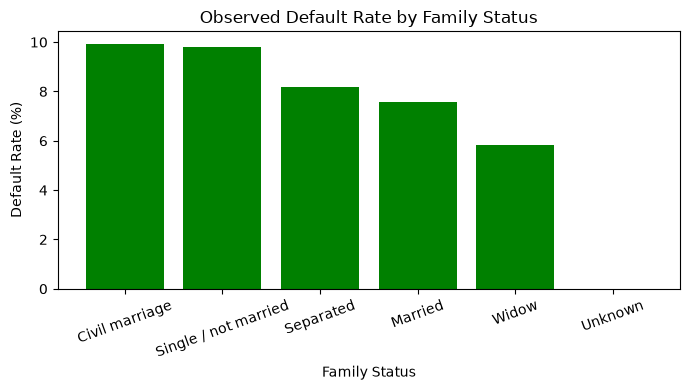

In [69]:
# Visualize observed default rate by family status
plt.figure(figsize=(7, 4))

plt.bar(
    family_status_default_rate.index,
    family_status_default_rate.values,
    color="green"
)

plt.title("Observed Default Rate by Family Status")
plt.xlabel("Family Status")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [70]:
# Check housing type categories
df["NAME_HOUSING_TYPE"].value_counts()

NAME_HOUSING_TYPE
House / apartment      272868
With parents            14840
Municipal apartment     11183
Rented apartment         4881
Office apartment         2617
Co-op apartment          1122
Name: count, dtype: int64

In [71]:
# Calculate observed default rate by housing type
housing_default_rate = (
    df.groupby("NAME_HOUSING_TYPE")["TARGET"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

housing_default_rate

NAME_HOUSING_TYPE
Rented apartment       12.31
With parents           11.70
Municipal apartment     8.54
Co-op apartment         7.93
House / apartment       7.80
Office apartment        6.57
Name: TARGET, dtype: float64

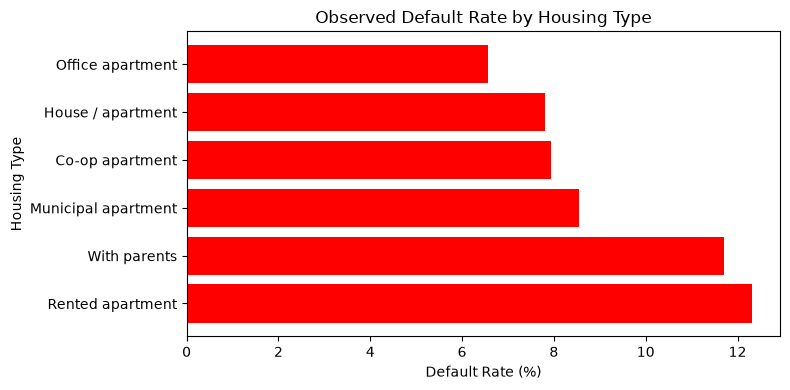

In [72]:
# Visualize observed default rate by housing type
plt.figure(figsize=(8, 4))

plt.barh(
    housing_default_rate.index,
    housing_default_rate.values,
    color="red"
)

plt.title("Observed Default Rate by Housing Type")
plt.xlabel("Default Rate (%)")
plt.ylabel("Housing Type")

plt.tight_layout()
plt.show()

In [73]:
# Select important numerical variables for correlation analysis
correlation_columns = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "AGE_YEARS",
    "EMPLOYMENT_YEARS",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS",
    "CREDIT_TO_INCOME",
    "ANNUITY_TO_INCOME",
    "TARGET"
]

correlation_matrix = df[correlation_columns].corr()

correlation_matrix.round(2)

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,AGE_YEARS,EMPLOYMENT_YEARS,CNT_CHILDREN,CNT_FAM_MEMBERS,CREDIT_TO_INCOME,ANNUITY_TO_INCOME,TARGET
AMT_INCOME_TOTAL,1.00,0.16,0.19,0.16,-0.03,0.01,0.01,0.02,-0.11,-0.15,-0.00
AMT_CREDIT,0.16,1.00,0.77,0.99,0.06,0.09,0.00,0.06,0.65,0.37,-0.03
AMT_ANNUITY,0.19,0.77,1.00,0.78,-0.01,0.05,0.02,0.08,0.39,0.48,-0.01
AMT_GOODS_PRICE,0.16,0.99,0.78,1.00,0.05,0.09,-0.00,0.06,0.63,0.37,-0.04
AGE_YEARS,-0.03,0.06,-0.01,0.05,1.00,0.35,-0.33,-0.28,0.12,0.08,-0.08
EMPLOYMENT_YEARS,0.01,0.09,0.05,0.09,0.35,1.00,-0.06,-0.03,0.07,0.02,-0.07
CNT_CHILDREN,0.01,0.00,0.02,-0.00,-0.33,-0.06,1.00,0.88,-0.02,-0.00,0.02
CNT_FAM_MEMBERS,0.02,0.06,0.08,0.06,-0.28,-0.03,0.88,1.00,0.05,0.06,0.01
CREDIT_TO_INCOME,-0.11,0.65,0.39,0.63,0.12,0.07,-0.02,0.05,1.00,0.79,-0.01
ANNUITY_TO_INCOME,-0.15,0.37,0.48,0.37,0.08,0.02,-0.00,0.06,0.79,1.00,0.01


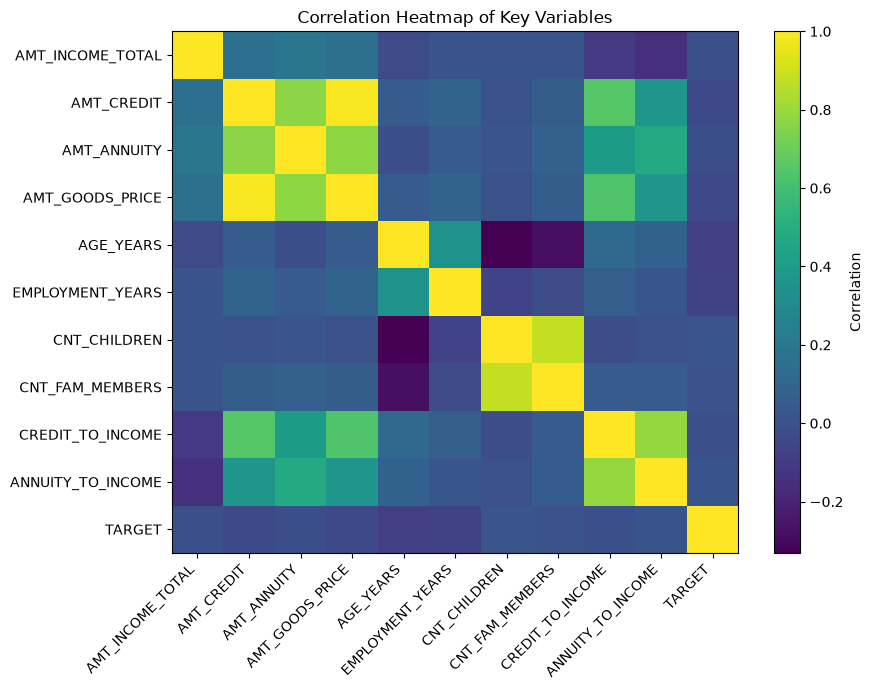

In [75]:
# Visualize correlation matrix
plt.figure(figsize=(9, 7))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Heatmap of Key Variables")

plt.tight_layout()
plt.show()

In [76]:
# Calculate observed default rate by age group and income group
age_income_default = (
    df.groupby(
        ["AGE_GROUP", "INCOME_GROUP"],
        observed=True
    )["TARGET"]
    .mean()
    .mul(100)
    .round(2)
    .reset_index(name="DEFAULT_RATE")
)

age_income_default

,AGE_GROUP,INCOME_GROUP,DEFAULT_RATE
0,20–30,High,10.59
1,20–30,Low,12.36
2,20–30,Middle,11.92
3,20–30,Very High,7.83
4,20–30,Very Low,12.73
5,31–40,High,9.20
6,31–40,Low,10.09
7,31–40,Middle,10.71
8,31–40,Very High,7.45
9,31–40,Very Low,10.82


In [77]:
# Sort age and income combinations by observed default rate
age_income_default.sort_values(
    "DEFAULT_RATE",
    ascending=False
).head(10)

,AGE_GROUP,INCOME_GROUP,DEFAULT_RATE
4,20–30,Very Low,12.73
1,20–30,Low,12.36
2,20–30,Middle,11.92
9,31–40,Very Low,10.82
7,31–40,Middle,10.71
0,20–30,High,10.59
6,31–40,Low,10.09
5,31–40,High,9.20
14,41–50,Very Low,8.20
11,41–50,Low,8.09


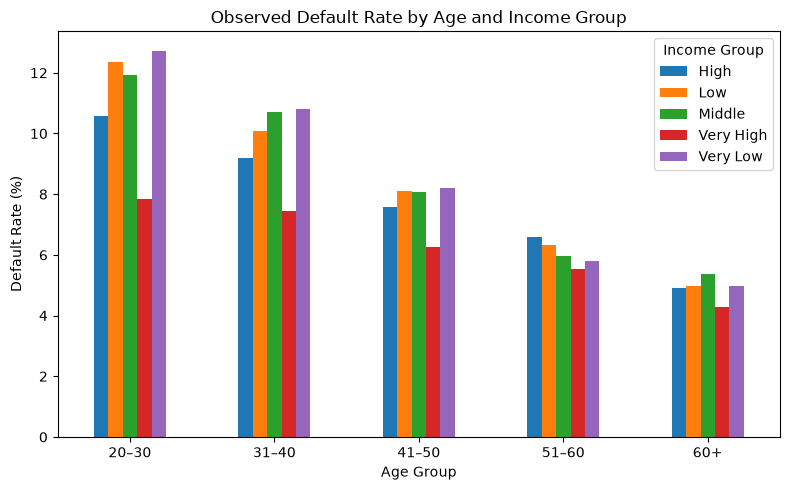

In [78]:
# Visualize observed default rate by age and income group
age_income_plot = age_income_default.pivot(
    index="AGE_GROUP",
    columns="INCOME_GROUP",
    values="DEFAULT_RATE"
)

age_income_plot.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Observed Default Rate by Age and Income Group")
plt.xlabel("Age Group")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)
plt.legend(title="Income Group")

plt.tight_layout()
plt.show()

In [79]:
# Calculate observed default rate by employment and income group
employment_income_default = (
    df.groupby(
        ["EMPLOYMENT_GROUP", "INCOME_GROUP"],
        observed=True
    )["TARGET"]
    .mean()
    .mul(100)
    .round(2)
    .reset_index(name="DEFAULT_RATE")
)

employment_income_default.head(15)

,EMPLOYMENT_GROUP,INCOME_GROUP,DEFAULT_RATE
0,10–20 Years,High,5.46
1,10–20 Years,Low,5.85
2,10–20 Years,Middle,6.11
3,10–20 Years,Very High,4.24
4,10–20 Years,Very Low,6.24
5,1–3 Years,High,11.02
6,1–3 Years,Low,11.74
7,1–3 Years,Middle,11.65
8,1–3 Years,Very High,9.12
9,1–3 Years,Very Low,11.39


In [80]:
# Sort employment and income combinations by observed default rate
employment_income_default.sort_values(
    "DEFAULT_RATE",
    ascending=False
).head(10)

,EMPLOYMENT_GROUP,INCOME_GROUP,DEFAULT_RATE
27,<1 Year,Middle,12.04
29,<1 Year,Very Low,11.94
6,1–3 Years,Low,11.74
26,<1 Year,Low,11.66
7,1–3 Years,Middle,11.65
9,1–3 Years,Very Low,11.39
19,3–5 Years,Very Low,11.36
5,1–3 Years,High,11.02
25,<1 Year,High,10.30
16,3–5 Years,Low,10.27


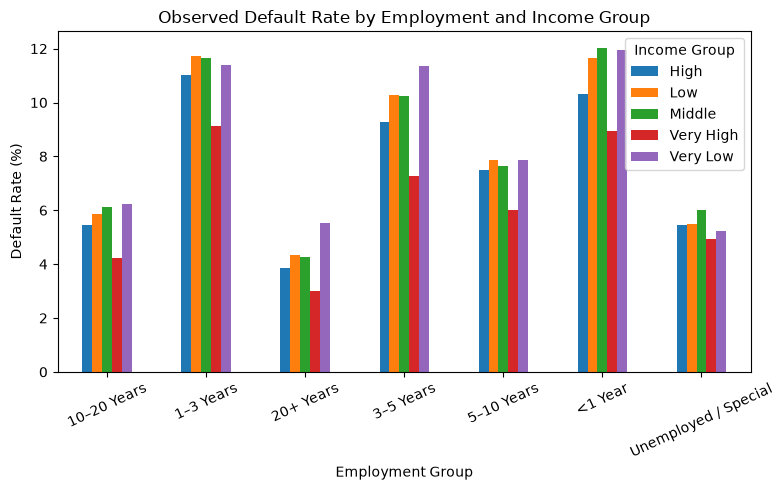

In [81]:
# Visualize observed default rate by employment and income group
employment_income_plot = employment_income_default.pivot(
    index="EMPLOYMENT_GROUP",
    columns="INCOME_GROUP",
    values="DEFAULT_RATE"
)

employment_income_plot.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Observed Default Rate by Employment and Income Group")
plt.xlabel("Employment Group")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=25)
plt.legend(title="Income Group")

plt.tight_layout()
plt.show()

In [83]:
# Calculate observed default rate by education and income group
education_income_default = (
    df.groupby(
        ["NAME_EDUCATION_TYPE", "INCOME_GROUP"],
        observed=True
    )["TARGET"]
    .mean()
    .mul(100)
    .round(2)
    .reset_index(name="DEFAULT_RATE")
)

education_income_default.head(15)

,NAME_EDUCATION_TYPE,INCOME_GROUP,DEFAULT_RATE
0,Academic degree,High,0.00
1,Academic degree,Low,0.00
2,Academic degree,Middle,0.00
3,Academic degree,Very High,4.84
4,Academic degree,Very Low,0.00
5,Higher education,High,5.59
6,Higher education,Low,5.51
7,Higher education,Middle,5.95
8,Higher education,Very High,4.50
9,Higher education,Very Low,5.96


In [84]:
# Sort education and income combinations by observed default rate
education_income_default.sort_values(
    "DEFAULT_RATE",
    ascending=False
).head(10)

,NAME_EDUCATION_TYPE,INCOME_GROUP,DEFAULT_RATE
17,Lower secondary,Middle,13.27
16,Lower secondary,Low,12.66
15,Lower secondary,High,11.70
22,Secondary / secondary special,Middle,9.48
19,Lower secondary,Very Low,9.29
21,Secondary / secondary special,Low,9.29
14,Incomplete higher,Very Low,9.28
20,Secondary / secondary special,High,9.08
11,Incomplete higher,Low,8.75
12,Incomplete higher,Middle,8.70


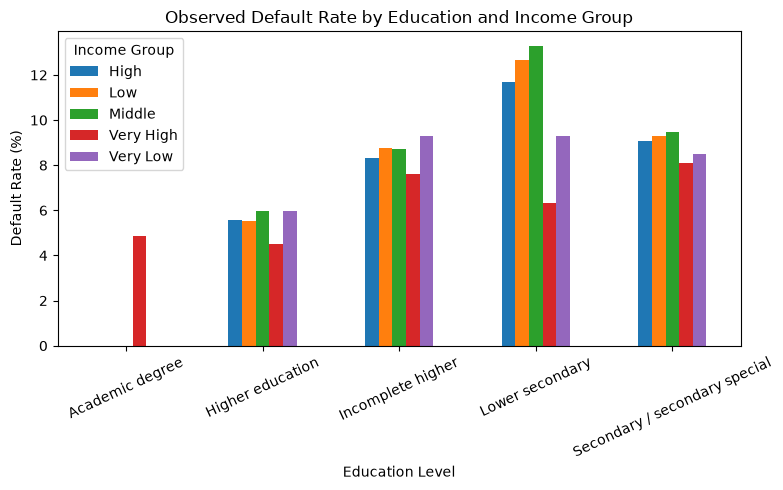

In [85]:
# Visualize observed default rate by education and income group
education_income_plot = education_income_default.pivot(
    index="NAME_EDUCATION_TYPE",
    columns="INCOME_GROUP",
    values="DEFAULT_RATE"
)

education_income_plot.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Observed Default Rate by Education and Income Group")
plt.xlabel("Education Level")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=25)
plt.legend(title="Income Group")

plt.tight_layout()
plt.show()

In [86]:
# Check final engineered dataset structure
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nEngineered / EDA Features:")
for col in [
    "AGE_YEARS",
    "AGE_GROUP",
    "EMPLOYMENT_YEARS",
    "EMPLOYMENT_GROUP",
    "INCOME_GROUP",
    "CREDIT_TO_INCOME",
    "ANNUITY_TO_INCOME",
    "CREDIT_TO_GOODS",
    "INCOME_PER_FAMILY_MEMBER",
    "CREDIT_TO_INCOME_BAND",
    "ANNUITY_TO_INCOME_BAND",
    "FAMILY_SIZE_GROUP",
    "CHILDREN_GROUP"
]:
    print(col, "✓" if col in df.columns else "✗")

Rows: 307511
Columns: 136

Engineered / EDA Features:
AGE_YEARS ✓
AGE_GROUP ✓
EMPLOYMENT_YEARS ✓
EMPLOYMENT_GROUP ✓
INCOME_GROUP ✓
CREDIT_TO_INCOME ✓
ANNUITY_TO_INCOME ✓
CREDIT_TO_GOODS ✓
INCOME_PER_FAMILY_MEMBER ✓
CREDIT_TO_INCOME_BAND ✓
ANNUITY_TO_INCOME_BAND ✓
FAMILY_SIZE_GROUP ✓
CHILDREN_GROUP ✓


In [87]:
# Final EDA summary statistics
eda_summary = {
    "Total Customers": df["SK_ID_CURR"].nunique(),
    "Total Applications": len(df),
    "Default Customers": (df["TARGET"] == 1).sum(),
    "Non-Default Customers": (df["TARGET"] == 0).sum(),
    "Default Rate (%)": round(df["TARGET"].mean() * 100, 2),
    "Average Income": round(df["AMT_INCOME_TOTAL"].mean(), 2),
    "Median Income": round(df["AMT_INCOME_TOTAL"].median(), 2),
    "Average Credit": round(df["AMT_CREDIT"].mean(), 2),
    "Median Credit": round(df["AMT_CREDIT"].median(), 2),
    "Average Annuity": round(df["AMT_ANNUITY"].mean(), 2),
}

pd.Series(eda_summary)

Total Customers          307511.00
Total Applications       307511.00
Default Customers         24825.00
Non-Default Customers    282686.00
Default Rate (%)              8.07
Average Income           168797.92
Median Income            147150.00
Average Credit           599026.00
Median Credit            513531.00
Average Annuity           27108.57
dtype: float64

#### Final EDA Observations

### Portfolio Overview
- The dataset contains 307,511 customer applications.
- There are 24,825 default customers and 282,686 non-default customers.
- The overall observed default rate is 8.07%.
- Average annual income is 168,797.92, while median income is 147,150.
- Average credit amount is 599,026, with a median of 513,531.
- Average annuity is 27,108.57.

### Demographic Observations
- Customers aged 20–30 show the highest observed default rate among the age groups.
- Lower secondary education has a substantially higher observed default rate than higher education groups.
- Male customers show a higher observed default rate than female customers in this dataset.
- Civil-marriage and single/not-married groups show relatively higher observed default rates.

### Income and Affordability
- The observed default rate varies across income groups.
- Credit-to-income and annuity-to-income ratios show differences across default groups.
- The 20–30% annuity-to-income band has the highest observed default rate among the defined bands.
- Higher affordability burdens should therefore be investigated further at the portfolio-monitoring level.

### Employment
- Customers with shorter employment histories show higher observed default rates.
- The <1 Year employment group has elevated observed default rates across several income groups.
- Employment stability appears to be an important descriptive dimension for further portfolio analysis.

### Family and Housing
- Customers with 3+ children show a higher observed default rate than customers with no children.
- Customers in the 5+ family-size group have the highest observed default rate among the family-size groups.
- Rented-apartment customers show the highest observed default rate among housing categories.

### Multivariate EDA
- Age and income together reveal stronger differences than either variable considered alone.
- The 20–30 + Very Low income combination has an observed default rate of 12.73%.
- Employment and income together show elevated observed default rates among shorter-tenure employment groups.
- Lower secondary education combined with Middle income has an observed default rate of 13.27%.

### Important Interpretation Rule
These analyses identify observed relationships and patterns in the Home Credit dataset.

Correlation or group-level differences do not prove causation. The findings should therefore be used for descriptive portfolio analysis, monitoring, and business insight generation rather than predictive claims.

In [88]:
# Save the final engineered dataset
output_path = r"D:\Home_credit\processed_data\application_train_engineered_final.csv"

df.to_csv(
    output_path,
    index=False
)

print("Final engineered dataset saved successfully!")
print("Location:", output_path)
print("Shape:", df.shape)

Final engineered dataset saved successfully!
Location: D:\Home_credit\processed_data\application_train_engineered_final.csv
Shape: (307511, 136)


In [89]:
# Verify the final engineered dataset
import os

print("File exists:", os.path.exists(output_path))

saved_df = pd.read_csv(output_path)

print("Saved dataset shape:", saved_df.shape)
print("Saved dataset columns:", len(saved_df.columns))

File exists: True
Saved dataset shape: (307511, 136)
Saved dataset columns: 136


In [90]:
import pandas as pd
df = pd.read_csv(r"D:\Home_credit\processed_data\application_train_engineered_final.csv")

print(df.columns.tolist())

['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELE